In [25]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay



In [7]:
final_df = pd.read_csv("../Output/final_df.csv", index_col=0)


In [8]:
print(final_df.info())
print(final_df.describe())


<class 'pandas.core.frame.DataFrame'>
Index: 4410 entries, 0 to 4409
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked       4410

In [13]:
# Colonnes constantes
constant_cols = [c for c in final_df.columns if final_df[c].nunique(dropna=False) == 1]
print("Colonnes constantes:", constant_cols)

# Suppression des colonnes constantes
df_clean = final_df.drop(columns=constant_cols).copy()
print("Shape apres nettoyage:", df_clean.shape)



['EmployeeCount', 'Over18', 'StandardHours']
Colonnes numériques: ['Age', 'DistanceFromHome', 'Education', 'EmployeeID', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'AvgWorkingHours', 'StdWorkingHours', 'TotalHours', 'DaysWorked', 'OvertimeDays', 'TotalOvertimeHours', 'AvgOvertimePerDay']
Colonnes catégorielles: ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


In [14]:
# ============================================
# 1) Separation target / features
# ============================================
TARGET = "Attrition"

X = df_clean.drop(columns=[TARGET]).copy()
y = df_clean[TARGET].copy()

# Encodage binaire de la target (Yes/No -> 1/0)
y = y.map({"Yes": 1, "No": 0})

# ============================================
# 2) Split stratifie
# ============================================
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(X, y):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y.iloc[train_idx].copy()
    y_test = y.iloc[test_idx].copy()

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)



Train: (3528, 32) (3528,)
Test : (882, 32) (882,)


In [ ]:
# ============================================
# 3bis) Detection des variables numeriques trop correlees (sans suppression ici)
# ============================================
corr_threshold = 0.9

num_cols_corr = X_train.select_dtypes(include=["number"]).columns
corr_abs = X_train[num_cols_corr].corr().abs()

# On garde uniquement la partie triangulaire superieure pour eviter les doublons
upper_triangle = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool))
cols_to_drop_corr = [col for col in upper_triangle.columns if any(upper_triangle[col] > corr_threshold)]

print(f"Seuil de correlation absolue: {corr_threshold}")
print(f"Colonnes candidates a supprimer (|corr| > {corr_threshold}): {len(cols_to_drop_corr)}")
print(cols_to_drop_corr)
print("Dimensions inchangees (avant comparaison):", X_train.shape, X_test.shape)


In [15]:
# ============================================
# 3) Pipeline de preprocessing
# ============================================
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Colonnes numeriques:", num_cols)
print("Colonnes categorielles:", cat_cols)

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])



Colonnes numeriques: ['Age', 'DistanceFromHome', 'Education', 'EmployeeID', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating', 'AvgWorkingHours', 'StdWorkingHours', 'TotalHours', 'DaysWorked', 'OvertimeDays', 'TotalOvertimeHours', 'AvgOvertimePerDay']
Colonnes categorielles: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


In [16]:
# ============================================
# 4) Fit sur train puis transform train/test
# ============================================
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

print("X_train_prepared:", X_train_prepared.shape)
print("X_test_prepared :", X_test_prepared.shape)



X_train_prepared: (3528, 52)
X_test_prepared : (882, 52)


Accuracy : 0.8651
Precision: 0.6769
Recall   : 0.3099
F1-score : 0.4251
ROC-AUC  : 0.8212

Classification report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       740
           1       0.68      0.31      0.43       142

    accuracy                           0.87       882
   macro avg       0.78      0.64      0.67       882
weighted avg       0.85      0.87      0.84       882



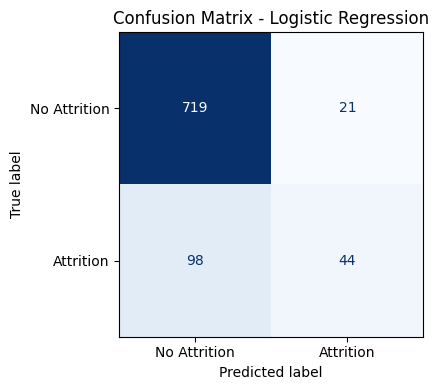

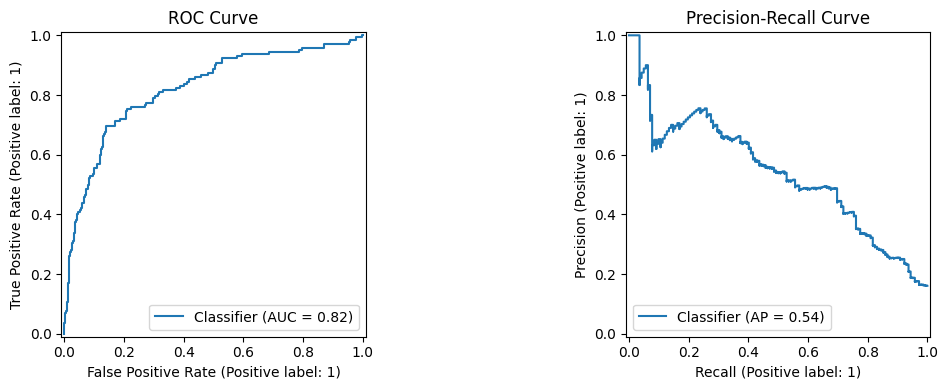

In [22]:
# ============================================
# 5) Logistic Regression + Graphiques
# ============================================
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_prepared, y_train)

y_pred = log_reg.predict(X_test_prepared)
y_proba = log_reg.predict_proba(X_test_prepared)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('Recall   :', round(recall_score(y_test, y_pred), 4))
print('F1-score :', round(f1_score(y_test, y_pred), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()



Accuracy : 0.9773
Precision: 1.0
Recall   : 0.8592
F1-score : 0.9242
ROC-AUC  : 0.9946

Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       740
           1       1.00      0.86      0.92       142

    accuracy                           0.98       882
   macro avg       0.99      0.93      0.96       882
weighted avg       0.98      0.98      0.98       882



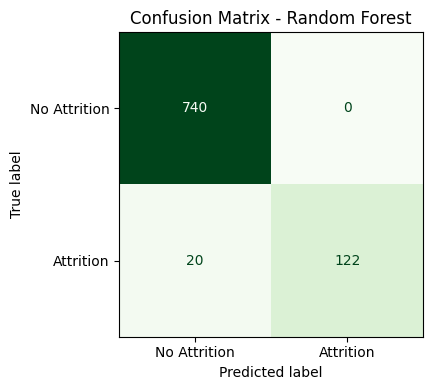

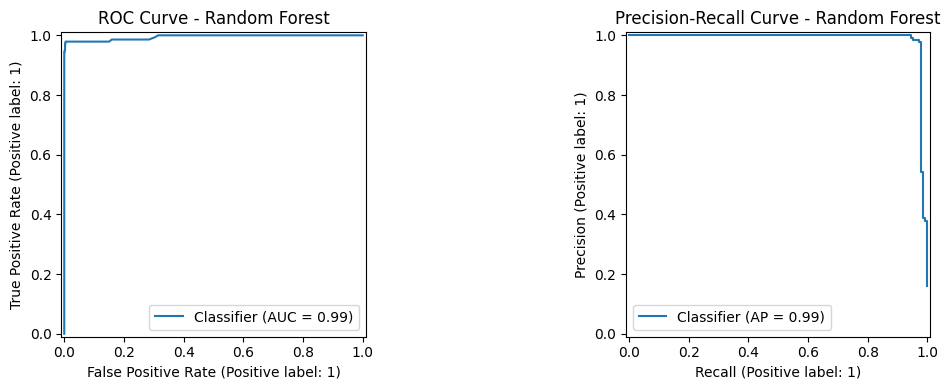

In [26]:
# ============================================
# 6) Random Forest Classifier + Graphiques
# ============================================
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced',
)
rf.fit(X_train_prepared, y_train)

y_pred_rf = rf.predict(X_test_prepared)
y_proba_rf = rf.predict_proba(X_test_prepared)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred_rf), 4))
print('Precision:', round(precision_score(y_test, y_pred_rf), 4))
print('Recall   :', round(recall_score(y_test, y_pred_rf), 4))
print('F1-score :', round(f1_score(y_test, y_pred_rf), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba_rf), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[0])
axes[0].set_title('ROC Curve - Random Forest')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - Random Forest')

plt.tight_layout()
plt.show()


Accuracy : 0.9875
Precision: 0.9852
Recall   : 0.9366
F1-score : 0.9603
ROC-AUC  : 0.9904

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       740
           1       0.99      0.94      0.96       142

    accuracy                           0.99       882
   macro avg       0.99      0.97      0.98       882
weighted avg       0.99      0.99      0.99       882


Classification report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       740
           1       1.00      0.86      0.92       142

    accuracy                           0.98       882
   macro avg       0.99      0.93      0.96       882
weighted avg       0.98      0.98      0.98       882



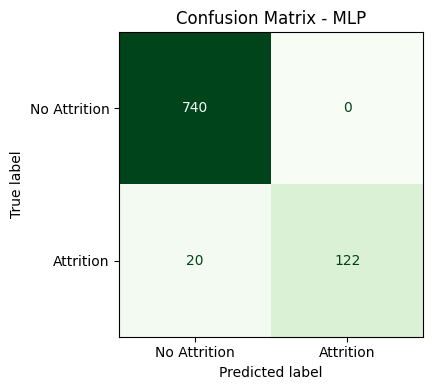

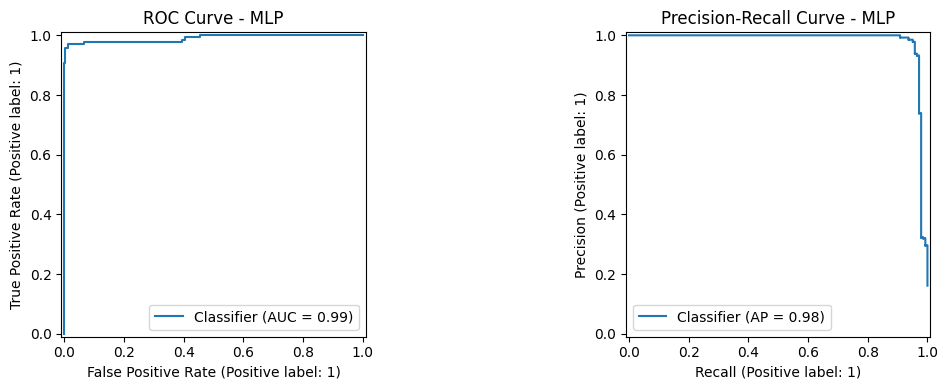

In [29]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_prepared, y_train)

y_pred_mlp = mlp.predict(X_test_prepared)
y_proba_mlp = mlp.predict_proba(X_test_prepared)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_mlp), 4))
print("Precision:", round(precision_score(y_test, y_pred_mlp), 4))
print("Recall   :", round(recall_score(y_test, y_pred_mlp), 4))
print("F1-score :", round(f1_score(y_test, y_pred_mlp), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_mlp), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred_mlp))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - MLP')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[0])
axes[0].set_title('ROC Curve - MLP')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - MLP')

plt.tight_layout()
plt.show()



In [ ]:
# ============================================
# 7) Matrice de correlation des colonnes donnees a l'IA
# ============================================
feature_names = full_pipeline.get_feature_names_out()

# Conversion en DataFrame pour faciliter le calcul de correlation
X_train_dense = X_train_prepared.toarray() if hasattr(X_train_prepared, "toarray") else X_train_prepared
X_train_prepared_df = pd.DataFrame(X_train_dense, columns=feature_names, index=X_train.index)

corr_matrix = X_train_prepared_df.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Matrice de correlation des features en entree modele (train)")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# 8) Suppression des variables numeriques trop correlees
# ============================================
# Utilise la liste detectee dans la cellule 3bis (|corr| > 0.9)
X_train = X_train.drop(columns=cols_to_drop_corr).copy()
X_test = X_test.drop(columns=cols_to_drop_corr).copy()

print(f"Colonnes supprimees: {len(cols_to_drop_corr)}")
print(cols_to_drop_corr)
print("Nouvelles dimensions train/test:", X_train.shape, X_test.shape)


In [ ]:
# ============================================
# 8bis) Suppression manuelle de variables inutiles
# ============================================
manual_cols_to_drop = ["Employee_ID"]

manual_removed = [col for col in manual_cols_to_drop if col in X_train.columns]
X_train = X_train.drop(columns=manual_cols_to_drop, errors="ignore").copy()
X_test = X_test.drop(columns=manual_cols_to_drop, errors="ignore").copy()

print("Colonnes supprimees manuellement:", manual_removed)
print("Dimensions train/test apres suppression manuelle:", X_train.shape, X_test.shape)


In [ ]:
# ============================================
# 3) Pipeline de preprocessing
# ============================================
num_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Colonnes numeriques:", num_cols)
print("Colonnes categorielles:", cat_cols)

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

full_pipeline = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols),
])



In [ ]:
# ============================================
# 4) Fit sur train puis transform train/test
# ============================================
X_train_prepared = full_pipeline.fit_transform(X_train)
X_test_prepared = full_pipeline.transform(X_test)

print("X_train_prepared:", X_train_prepared.shape)
print("X_test_prepared :", X_test_prepared.shape)



In [ ]:
# ============================================
# 5) Logistic Regression + Graphiques
# ============================================
log_reg = LogisticRegression(max_iter=2000, random_state=42)
log_reg.fit(X_train_prepared, y_train)

y_pred = log_reg.predict(X_test_prepared)
y_proba = log_reg.predict_proba(X_test_prepared)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
print('Precision:', round(precision_score(y_test, y_pred), 4))
print('Recall   :', round(recall_score(y_test, y_pred), 4))
print('F1-score :', round(f1_score(y_test, y_pred), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Blues',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[0])
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()



In [ ]:
# ============================================
# 6) Random Forest Classifier + Graphiques
# ============================================
rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced',
)
rf.fit(X_train_prepared, y_train)

y_pred_rf = rf.predict(X_test_prepared)
y_proba_rf = rf.predict_proba(X_test_prepared)[:, 1]

print('Accuracy :', round(accuracy_score(y_test, y_pred_rf), 4))
print('Precision:', round(precision_score(y_test, y_pred_rf), 4))
print('Recall   :', round(recall_score(y_test, y_pred_rf), 4))
print('F1-score :', round(f1_score(y_test, y_pred_rf), 4))
print('ROC-AUC  :', round(roc_auc_score(y_test, y_proba_rf), 4))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=axes[0])
axes[0].set_title('ROC Curve - Random Forest')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_rf, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - Random Forest')

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    learning_rate_init=1e-3,
    max_iter=300,
    random_state=42
)

mlp.fit(X_train_prepared, y_train)

y_pred_mlp = mlp.predict(X_test_prepared)
y_proba_mlp = mlp.predict_proba(X_test_prepared)[:, 1]

print("Accuracy :", round(accuracy_score(y_test, y_pred_mlp), 4))
print("Precision:", round(precision_score(y_test, y_pred_mlp), 4))
print("Recall   :", round(recall_score(y_test, y_pred_mlp), 4))
print("F1-score :", round(f1_score(y_test, y_pred_mlp), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_proba_mlp), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred_mlp))

print('\nClassification report:')
print(classification_report(y_test, y_pred_rf))

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=['No Attrition', 'Attrition'],
    cmap='Greens',
    ax=ax,
    colorbar=False,
)
ax.set_title('Confusion Matrix - MLP')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[0])
axes[0].set_title('ROC Curve - MLP')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_mlp, ax=axes[1])
axes[1].set_title('Precision-Recall Curve - MLP')

plt.tight_layout()
plt.show()

